In [1]:
!pip install -q sparkmeasure pyspark

In [2]:
from pyspark import SparkContext
from pyspark import SparkConf
from pyspark.sql import SparkSession
from sparkmeasure import StageMetrics
from sparkmeasure import TaskMetrics
import os
import math

# for each node u, this function emits pairs with neighbouring nodes v (u, v)
# the node u with itself is also included (u, u) (required for similarity calculation)
def adj_list_mapper(line):
    # input: u, v
    try:
        u, v = line.split(',')
    except ValueError:
        # Log a warning or skip the malformed line
        print(f"Warning: Skipping malformed line in adj_list_mapper: {line}")
        return [] # Return an empty list to skip this line

    # emit both directions so each node "sees" its neighbour
    # yield streams each of four items one by one to flatMap
    # rather than storing four items in memory for each line of input file
    yield (u, v)
    yield (v, u)
    yield (u, u)
    yield (v, v)

# this function sorts the list of neighbours for each vertex
def adj_list_reducer(vertex, neighbours):
    # the shuffle/sort group by phase has grouped all neighbours for this vertex
    # sort them to make finding intersections more efficient (O(n))
    sorted_neighbors = sorted(list(set(neighbours)))

    # output: vertex u and its sorted adjacency list
    return (vertex, sorted_neighbors)

In [3]:
# environment prep
os.environ['PYARROW_IGNORE_TIMEZONE'] = '1'

from pyspark import StorageLevel

# stop any ghost sessions properly
active_spark = SparkSession.getActiveSession()
if active_spark:
    active_spark.stop()

# configuration
# .master("local[*]") changed to .master("local[6]") to force use of more than 2 cores
spark = SparkSession.builder \
    .appName("PSCAN_Colab_Optimized") \
    .master("local[6]") \
    .config("spark.jars.packages", "ch.cern.sparkmeasure:spark-measure_2.13:0.27") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.kryoserializer.buffer.max", "12m") \
    .config("spark.default.parallelism", "18") \
    .config("spark.sql.shuffle.partitions", "18") \
    .config("spark.memory.fraction", "0.5") \
    .getOrCreate()

NUM_PARTITIONS = 18
# entry points
sc = spark.sparkContext

taskmetrics = TaskMetrics(spark)

# load data
# minPartitions suggests to Spark how to split input file
rdd_loaded = sc.textFile("/content/sample_data/edges_co.csv", minPartitions = NUM_PARTITIONS)

# skip the header row
header = rdd_loaded.first()
rdd_data = rdd_loaded.filter(lambda line: line != header)

# force the number of partitions to exactly 12 using repartition
rdd = rdd_data.repartition(NUM_PARTITIONS)
rdd.persist(StorageLevel.MEMORY_AND_DISK)
rdd.count() # force repartitioning now to get per partition reports
# begin metrics after repartitioning
taskmetrics.begin()

# apply adjacency list mapper
mapped_rdd = rdd.flatMap(adj_list_mapper)

# group by key and apply adjacency list reducer
reduced_rdd = mapped_rdd.groupByKey().mapValues(list).map(lambda x: adj_list_reducer(x[0], x[1]))

In [4]:
# this function produces an edge key (node A, node B) and its full adjacency list
def struct_sim_mapper(pair):
    # input:  u is a vertex and neighbours is its adjacency list
    # adjacency list include the node u
    u, neighbours = pair
    # print(f"Processing node: {u}, with neighbours: {neighbours}")

    for v in neighbours:
        edge_key = tuple(sorted((u, v))) # the edge key is (node A, node B)
        # print(f"  For edge component v: {v}, generated key: {edge_key}, broadcasting {neighbours}")
        # yield each item one by one (rather than storing in memory)
        yield (edge_key, neighbours)

# apply flatMap with the structural similarity mapper function
shuffled_edges = reduced_rdd.flatMap(struct_sim_mapper)


In [5]:
# this function performs the "intersection" logic and computes structural similarity
epsilon = 0.41

def struct_sim_reducer(edge_key, lists):
    # ensure we have both neighbourhoods for the edge
    if len(lists) < 2:
        return None

    # convert lists to sets for efficient intersection
    n_u = set(lists[0])
    n_v = set(lists[1])

    # calculate intersection size
    intersection = len(n_u.intersection(n_v))

    # calculate Jaccard Similarity (sigma)
    # |N(u) intersect N(v)| / sqrt(|N(u)| * |N(v)|)
    denominator = math.sqrt(len(n_u) * len(n_v))
    if denominator == 0: # Avoid division by zero
        sigma = 0.0
    else:
        sigma = intersection / denominator

    # check against the epsilon threshold
    # the higher epsilon, the fewer clusters
    if sigma >= epsilon:
        return (edge_key, sigma)
    # if similarity below epsilon do not return edge
    return None

# group by edge key
grouped_shuffled_edges = shuffled_edges.groupByKey(numPartitions=NUM_PARTITIONS)

# use reducer to calculate similarity
similarities_rdd = grouped_shuffled_edges.map(lambda x: struct_sim_reducer(x[0], list(x[1])))

# filter out non-similar edges (where struct_sim_reducer returned None)
similar_edges = similarities_rdd.filter(lambda x: x is not None)


similar_edges.persist(StorageLevel.MEMORY_AND_DISK)

PythonRDD[17] at RDD at PythonRDD.scala:56

In [6]:
from collections import defaultdict
# for each node, this function broadcasts its current label to itself
# and its similar neighbours
def label_prop_mapper(vertex_id, current_label, neighbours_list):
    # input: node vertex, current label, list of neighbour vertices
    # a node informs itself of its own label (to keep it)
    yield (vertex_id, current_label)

    # a node tells all its "similar" neighbours its label
    # only applies to neighbours that passed the epsilon-cut
    if isinstance(neighbours_list, (list, tuple)):
        for neighbour_item in neighbours_list:
            yield (neighbour_item, current_label)
    else:
        # ensure neighbours_list is a list or tuple to iterate safely
        print("Error case skipped.")

# get all unique nodes involved in similar edges
# note that distinct() defaults to 2 partitions

# similar_edges is ((u, v), sigma)
# map to both directions: (u, v) and (v, u)
# filter out self-loops if they exist
similar_neighbour_pairs_rdd = similar_edges.flatMap(lambda x: [
    (x[0][0], x[0][1]),
    (x[0][1], x[0][0])
]).filter(lambda x: x[0] != x[1])

# group by the first node and convert to list
node_to_similar_neighbours_rdd = (similar_neighbour_pairs_rdd
    .groupByKey()
    .mapValues(list)
    .persist(StorageLevel.MEMORY_AND_DISK))

# get the initial labels (nodeID, nodeID) from adjacency list
initial_labels_rdd = node_to_similar_neighbours_rdd.map(lambda x: (x[0], x[0]))


In [7]:
import math
import os

# this function applies the minimum label to a cluster of similar nodes
def label_prop_reducer(propagated_labels_rdd):
    # choose minimum label for each node
    return propagated_labels_rdd.reduceByKey(min)

# initialize current labels for the iterative process
# start with the initial_labels_rdd where each node is its own label
current_labels_rdd = initial_labels_rdd.persist(StorageLevel.MEMORY_AND_DISK)

max_iterations = 150 # set a maximum number of iterations to prevent infinite loops
iteration = 0
converged = False
print("--- Pre-Loop Partition & Cache Check ---")

rdds_to_check = [
    ("Main Graph (rdd)", rdd),
    ("Similar Edges", similar_edges),
    ("Initial Labels", initial_labels_rdd),
    ("Current Labels", current_labels_rdd)
]

for name, rdd_obj in rdds_to_check:
    p_count = rdd_obj.getNumPartitions()
    is_cached = rdd_obj.getStorageLevel().useMemory

    status = "✅ OK" if p_count == NUM_PARTITIONS else "❌ MISMATCH (Expected 128)"
    cache_status = "🧠 Cached" if is_cached else "⚠️ NOT CACHED (Will be slow!)"

    print(f"{name}: {p_count} partitions {status} | {cache_status}")

print("-" * 40)

# check for matching numbers of partitions in key rdds
if any(r[1].getNumPartitions() != NUM_PARTITIONS for r in rdds_to_check):
    print("CRITICAL: Partition mismatch detected.")

# checkpoint
checkpoint_path = os.path.join(os.getcwd(), "spark_checkpoints")
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)
sc.setCheckpointDir(checkpoint_path)

# initialize current labels
current_labels_rdd = initial_labels_rdd.persist(StorageLevel.MEMORY_AND_DISK)
iteration = 0
converged = False

while not converged and iteration < max_iterations:
    iteration += 1
    print(f"\nIteration {iteration}")

    # join current labels with the similar neighbour vertex lists
    # result: (vertex_id, (current_label, similar_neighbours_list))
    # use leftOuterJoin to make sure node_to_similar_neighbours_rdd contains all nodes we are interested in
    labeled_similar_graph_rdd = current_labels_rdd.leftOuterJoin(node_to_similar_neighbours_rdd)

    # filter out nodes that do not have any similar neighbours
    # let nodes keep their own label if their neighbors list is None
    # take care of case where neighbours_list is None

    # apply one iteration of label_prop_mapper
    # mapper will emit (neighbour, propagated_label) for each neighbour
    # x[0] is id of current node, x[1][0] is label assigned to node, x[1][1] is list of neighbours
    # if no neighbours, pass back empty list
    propagated_labels_rdd = labeled_similar_graph_rdd.flatMap(
        lambda x: label_prop_mapper(x[0], x[1][0], x[1][1] if x[1][1] is not None else []))

    # use reducer to choose minimum label for each node
    new_labels_rdd = label_prop_reducer(propagated_labels_rdd)

    # truncate lineage every 10 iterations
    if iteration % 10 == 0:
        new_labels_rdd.checkpoint()

    # check for convergence using distributed approach
    # join rdds and count the number of nodes whose labels have changed
    # result: (vertex_id, (current_label, new_label))
    joined_labels = current_labels_rdd.join(new_labels_rdd)

    # filter for nodes where the label has changed and count them
    changed_labels_count = joined_labels.filter(lambda x: x[1][0] != x[1][1]).count()

    if changed_labels_count == 0:
        converged = True
        print(f"✅ Algorithm converged after {iteration} iterations")
    else:
        # update labels for the next iteration
        new_labels_rdd.persist(StorageLevel.MEMORY_AND_DISK)
        current_labels_rdd.unpersist()
        current_labels_rdd = new_labels_rdd
        print(f"Labels updated and propagation continuing. Nodes with changed labels: {changed_labels_count}")

if iteration == max_iterations and not converged:
    print(f"Maximum iterations ({max_iterations}) reached without convergence")
else:
    print(f"Final labels ready after {iteration} iterations.")
# collect and sort results for printing
final_labels = current_labels_rdd.collect()
final_labels.sort(key=lambda x: (int(x[1]), int(x[0])))

# group nodes by their final labels to represent clusters
clusters = {}
for node, label in final_labels:
    clusters.setdefault(label, []).append(node)

taskmetrics.end()

# sort clusters by size (number of nodes) in descending order
sorted_clusters = sorted(clusters.items(), key=lambda item: len(item[1]), reverse=True)

print("Epsilon = ", epsilon)
print(f"Total number of clusters found: {len(sorted_clusters)}")
print("\nTop 10 Clusters (according to number of nodes in cluster):")

output_filename = "top_10_clusters.txt"
with open(output_filename, "w") as f:
    f.write("Top 10 Clusters (according to number of nodes in cluster):\n")
    # store nodes from top 10 clusters for edge counting
    top_10_cluster_nodes = set()
    # print and write only the top 10 clusters
    for i, (label, nodes) in enumerate(sorted_clusters):
        if i >= 10:
            break
        # add nodes to set
        top_10_cluster_nodes.update(nodes)
        # write full details to file
        f.write(f"Cluster {label}: {len(nodes)} nodes - Nodes: {', '.join(sorted(nodes, key=int))}\n")

        print(f"Cluster {label}: {len(nodes)} nodes")
print(f"\nFull cluster details for the top 10 clusters saved to {output_filename}")

# top 10 clusters
top_10_nodes_broadcast = sc.broadcast(top_10_cluster_nodes)

edges_in_top_10_clusters_rdd = similar_edges.filter(
    lambda edge_tuple: \
        edge_tuple[0][0] in top_10_nodes_broadcast.value and \
        edge_tuple[0][1] in top_10_nodes_broadcast.value
)

num_edges_in_top_10_clusters = edges_in_top_10_clusters_rdd.count()
print(f"Total number of edges within the top 10 clusters: {num_edges_in_top_10_clusters}")

--- Pre-Loop Partition & Cache Check ---
Main Graph (rdd): 18 partitions ✅ OK | 🧠 Cached
Similar Edges: 18 partitions ✅ OK | 🧠 Cached
Initial Labels: 18 partitions ✅ OK | 🧠 Cached
Current Labels: 18 partitions ✅ OK | 🧠 Cached
----------------------------------------

Iteration 1
Labels updated and propagation continuing. Nodes with changed labels: 210395

Iteration 2
Labels updated and propagation continuing. Nodes with changed labels: 131869

Iteration 3
Labels updated and propagation continuing. Nodes with changed labels: 67243

Iteration 4
Labels updated and propagation continuing. Nodes with changed labels: 44171

Iteration 5
Labels updated and propagation continuing. Nodes with changed labels: 30654

Iteration 6
Labels updated and propagation continuing. Nodes with changed labels: 22281

Iteration 7
Labels updated and propagation continuing. Nodes with changed labels: 16979

Iteration 8
Labels updated and propagation continuing. Nodes with changed labels: 13091

Iteration 9
Labels

In [8]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

partition_data = taskmetrics.create_taskmetrics_DF()

# identify loop stages (with NUM_PARTITIONS tasks)
valid_stages = partition_data.groupBy("stageId").count().filter(F.col("count") == NUM_PARTITIONS)

# join to original data
window_spec = Window.partitionBy("stageId").orderBy("index")

aligned_data = partition_data.join(valid_stages.select("stageId"), "stageId") \
    .withColumn("logical_partition_id", F.row_number().over(window_spec) - 1)

# collect partition profiles
partition_profile = aligned_data.groupBy("logical_partition_id") \
    .agg(
        F.sum("executorRunTime").alias("total_execution_time_ms"),
        F.avg("executorRunTime").alias("avg_ms_per_stage"),
        F.max("executorRunTime").alias("slowest_single_task_ms")
    ) \
    .orderBy("logical_partition_id")

# print
partition_profile.show(NUM_PARTITIONS, truncate=False)

+--------------------+-----------------------+------------------+----------------------+
|logical_partition_id|total_execution_time_ms|avg_ms_per_stage  |slowest_single_task_ms|
+--------------------+-----------------------+------------------+----------------------+
|0                   |1152071                |6659.369942196532 |11665                 |
|1                   |1164178                |6729.35260115607  |12087                 |
|2                   |1163535                |6725.635838150289 |12361                 |
|3                   |1170630                |6766.64739884393  |11486                 |
|4                   |1185234                |6851.063583815029 |11938                 |
|5                   |1164048                |6728.601156069364 |10870                 |
|6                   |1160813                |6709.901734104046 |15405                 |
|7                   |1155583                |6679.670520231214 |12285                 |
|8                   

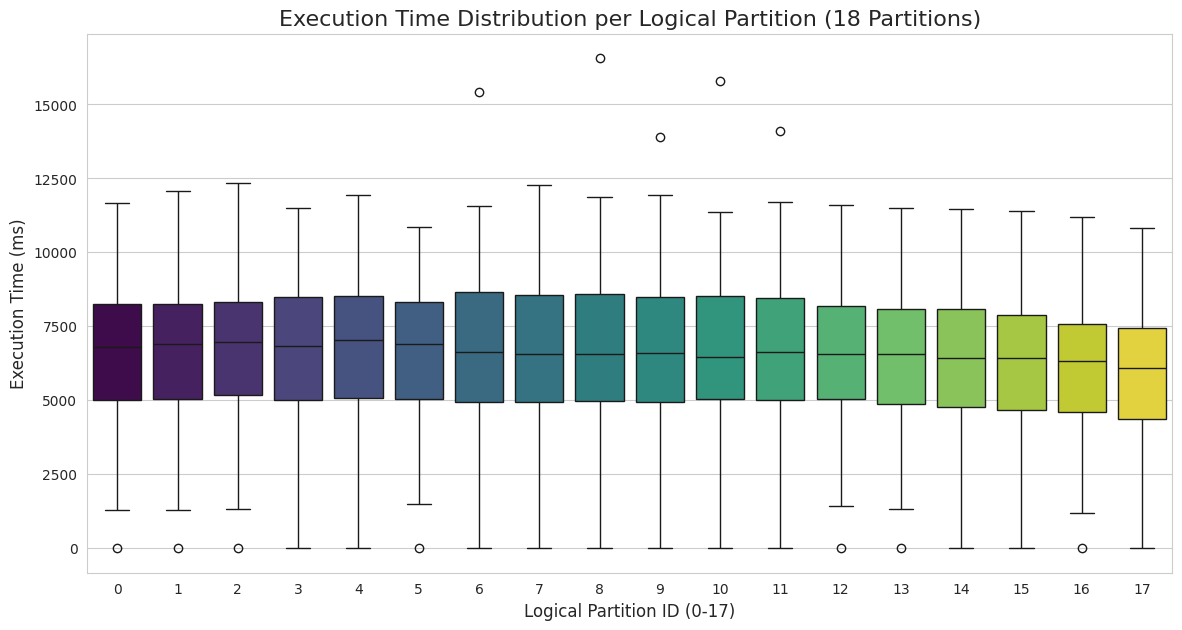

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot box plots for each partition
plot_df = aligned_data.select("logical_partition_id", "executorRunTime").toPandas()

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.boxplot(data=plot_df,
            x='logical_partition_id',
            y='executorRunTime',
            hue='logical_partition_id',
            legend=False,
            palette="viridis")

plt.title(f'Execution Time Distribution per Logical Partition ({NUM_PARTITIONS} Partitions)', fontsize=16)
plt.xlabel(f'Logical Partition ID (0-{NUM_PARTITIONS-1})', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)

plt.show()

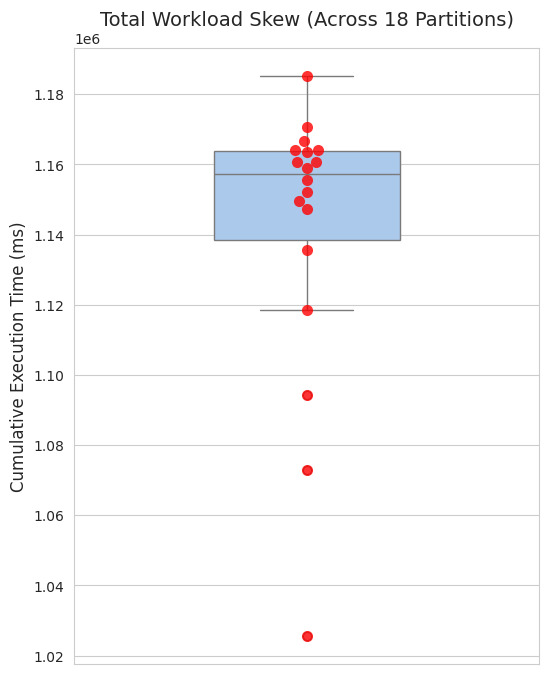

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# aggregate for each partition
partition_sums_pd = aligned_data.groupBy("logical_partition_id") \
    .agg(F.sum("executorRunTime").alias("total_work_ms")) \
    .toPandas()

# create box plot
plt.figure(figsize=(6, 8))
sns.set_style("whitegrid")
sns.boxplot(y="total_work_ms", data=partition_sums_pd, color="#a1c9f4", width=0.4)

# overlay individual partition times
sns.swarmplot(y="total_work_ms", data=partition_sums_pd, color="red", size=8, alpha=0.8)

plt.title(f"Total Workload Skew (Across {NUM_PARTITIONS} Partitions)", fontsize=14)
plt.ylabel("Cumulative Execution Time (ms)", fontsize=12)
plt.xticks([]) # Hide x-axis since there's only one category

plt.show()